In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [ ]:
df = pd.read_csv('Final_df.csv')
semantic = pd.read_csv('Semantic_scores.csv')
grammar = pd.read_csv('grammar_quality_score.csv')
keyword = pd.read_csv('keyword_score.csv')

In [ ]:
new_df = pd.concat([semantic, grammar, keyword, df['Score']], axis=1)

In [ ]:
new_df.head()

,semantic_similarity,grammar_score,keyword_score,Score
0,0.866848,0.5,0.176471,1.00
1,0.651658,1.0,0.121951,0.95
2,0.915449,1.0,0.342105,1.00
3,0.915531,1.0,0.346154,1.00
4,0.875637,1.0,0.250000,1.00


In [ ]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2620 entries, 0 to 2619
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   semantic_similarity  2620 non-null   float64
 1   grammar_score        2620 non-null   float64
 2   keyword_score        2620 non-null   float64
 3   Score                2620 non-null   float64
dtypes: float64(4)
memory usage: 82.0 KB


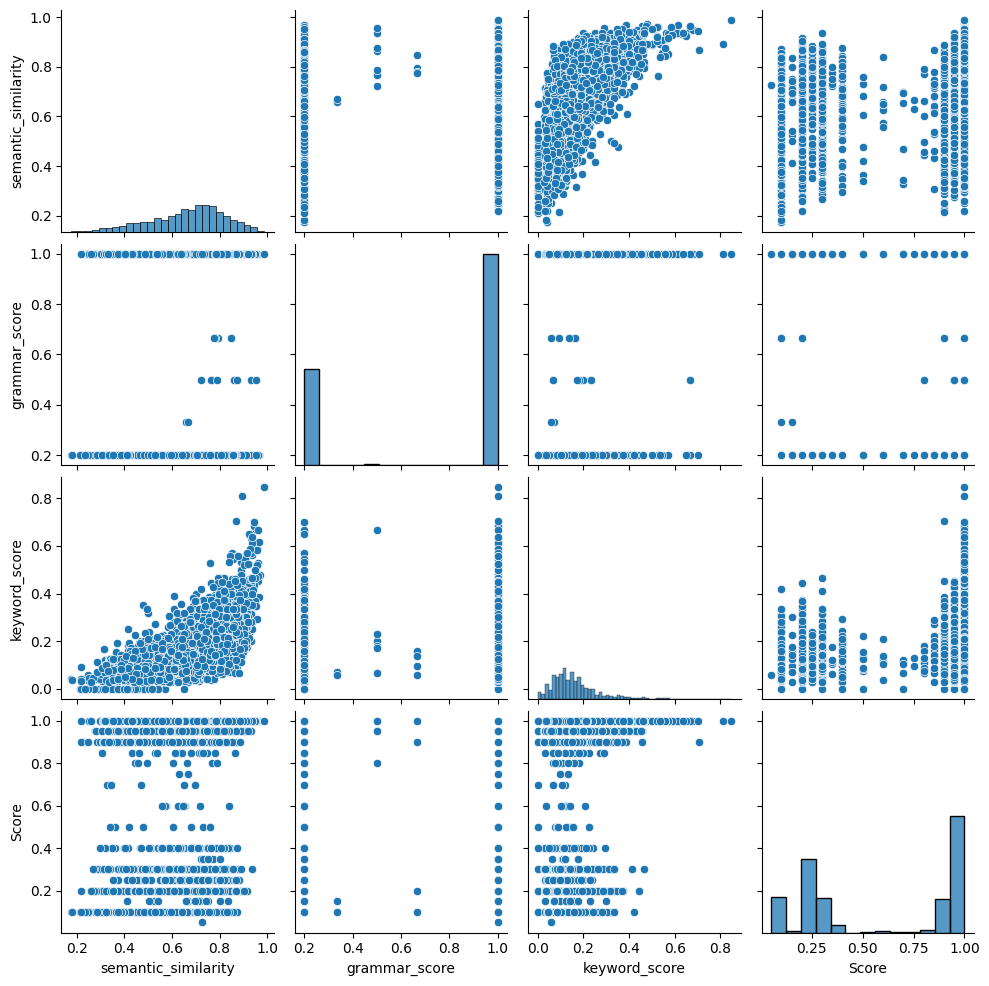

In [ ]:
sns.pairplot(new_df)

<Axes: >

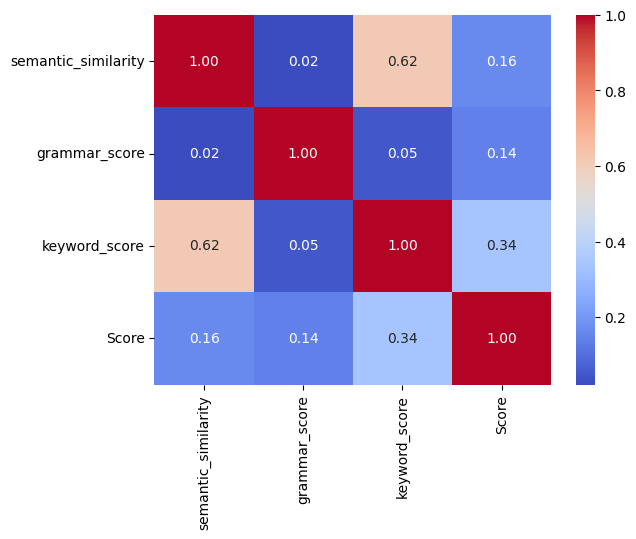

In [ ]:
sns.heatmap(new_df.corr(),annot=True,cmap='coolwarm',fmt='.2f')

In [ ]:
X = new_df.drop('Score', axis=1)
y = new_df['Score']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'SVR': SVR(),
    'XGBoost': XGBRegressor(random_state=42)
}

In [ ]:
best_model = None
best_score = float('-inf')
model_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    score = r2_score(y_test, y_pred)
    model_pipelines[name] = pipe

    print(f"\n📊 {name}")
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R² Score:", score)

    if score > best_score:
        best_score = score
        best_model_name = name
        best_model = pipe



📊 Linear Regression
MSE: 0.1203843573699153
R² Score: 0.13091802071773528

📊 Random Forest
MSE: 0.1477328458969466
R² Score: -0.06651692065439385

📊 Gradient Boosting
MSE: 0.11637486024224278
R² Score: 0.15986348984489784

📊 SVR
MSE: 0.1279800582002917
R² Score: 0.07608293370210961

📊 XGBoost
MSE: 0.15671212381777236
R² Score: -0.1313403644842066


In [ ]:
# Predict using the best model
best_predictions = best_model.predict(X_test)

print(f"\n✅ Best model: {best_model_name}")
print("Predictions from best model:\n", best_predictions)



✅ Best model: Gradient Boosting
Predictions from best model:
 [0.57447507 0.58930953 0.51228735 0.46022557 0.33280868 0.61643378
 0.81339704 0.65783267 0.42020074 0.35743673 0.79167031 0.57198472
 0.73177663 0.43962223 0.39457042 0.98235833 0.41071259 0.76763661
 0.469328   0.70040027 0.5753004  0.50635675 0.82973694 0.50888261
 0.63234419 0.7529229  0.43682718 0.57923626 0.71287761 0.62376986
 0.8807071  0.54117285 0.59998838 0.57799905 0.93631003 0.45615271
 0.53724509 0.56540967 0.51670805 0.83485144 0.64895029 0.85933991
 0.47294751 0.51391193 0.53793838 0.60570522 0.42657391 0.4699732
 0.52683241 0.42133995 0.3873011  0.53724509 0.98267785 0.81607006
 0.39026216 0.98072589 0.41131244 0.65307448 0.45853015 0.43284458
 0.50231285 0.49677365 0.57303124 0.82673152 0.47645664 0.42519459
 0.44410631 0.93981923 0.59262593 0.86301456 0.58208938 0.42842804
 0.5203126  0.66997946 0.58734591 0.67542532 0.81607006 0.51005989
 0.47504535 0.89156509 0.65713704 0.4896961  0.58885434 0.45964491


In [ ]:
training_predictions = best_model.predict(X_train)
testing_predictions = best_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error

train_mae = mean_absolute_error(y_train, training_predictions)
test_mae = mean_absolute_error(y_test, testing_predictions)

print("Training MAE:", train_mae*10)
print("Testing MAE:", test_mae*10)

Training MAE: 2.825188273516153
Testing MAE: 3.0325139291490655


In [ ]:
predictions = best_model.predict(X)

In [ ]:
mae = mean_absolute_error(y, predictions)
print("Mean Absolute Error of complete dataset:", mae*10)

Mean Absolute Error of complete dataset: 2.8666534046427357


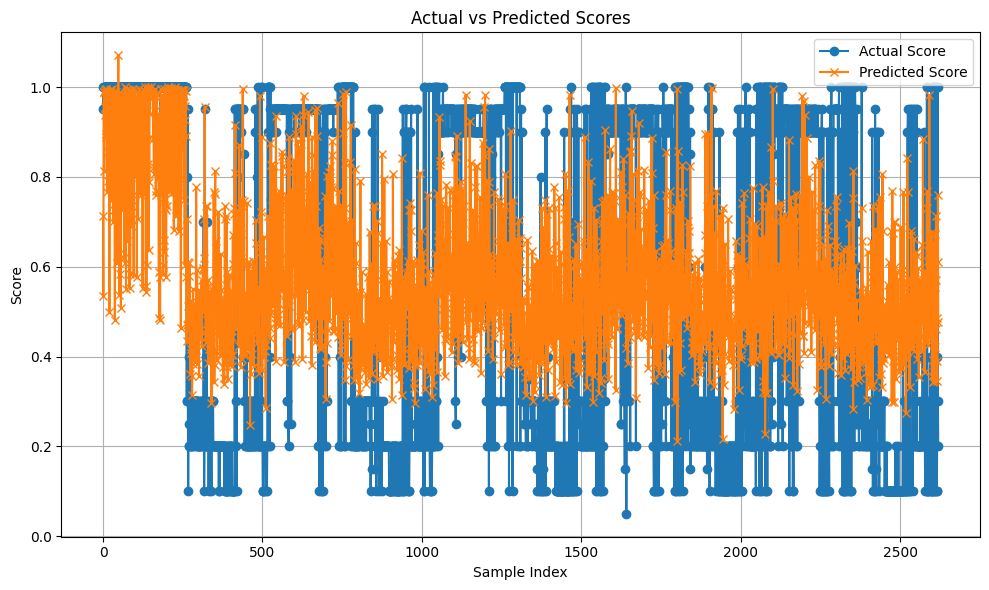

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(y, label='Actual Score', marker='o')
plt.plot(predictions, label='Predicted Score', marker='x')
plt.title('Actual vs Predicted Scores')
plt.xlabel('Sample Index')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import joblib
joblib.dump(best_model, 'best_model.pkl')

['best_model.pkl']